In [2]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [4]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        50   (2094, 964)   float32   


In [5]:
image_cut = image[65:165, 0:1890]
image_error_cut = image_error[65:165, 0:1890]

Text(0.5, 0, 'wavelength')

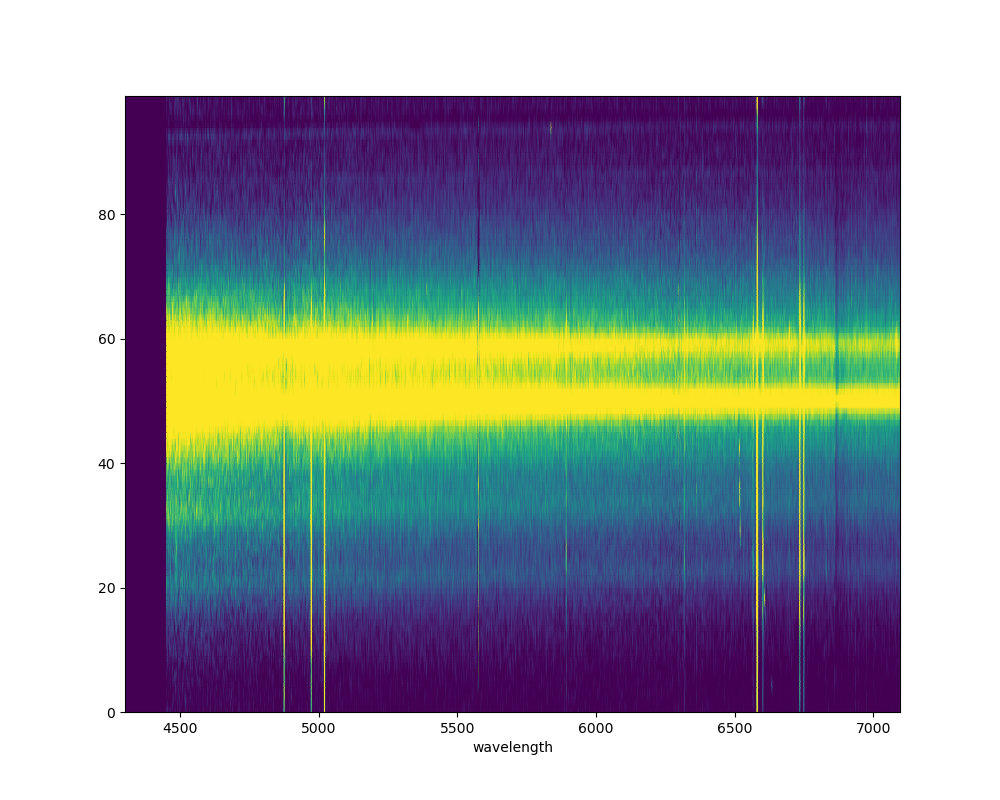

In [6]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [7]:
z = 0.00323
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/PSF/Real_seeing_NGC5058.txt")
sigmas = seeing / 2.35
n_component = 5
print(sigmas)

[1.34489793 1.48843306 1.34129394 1.31750216 1.49850846 1.35106383]


In [8]:
l_HA

6584.198490000001

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        50   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

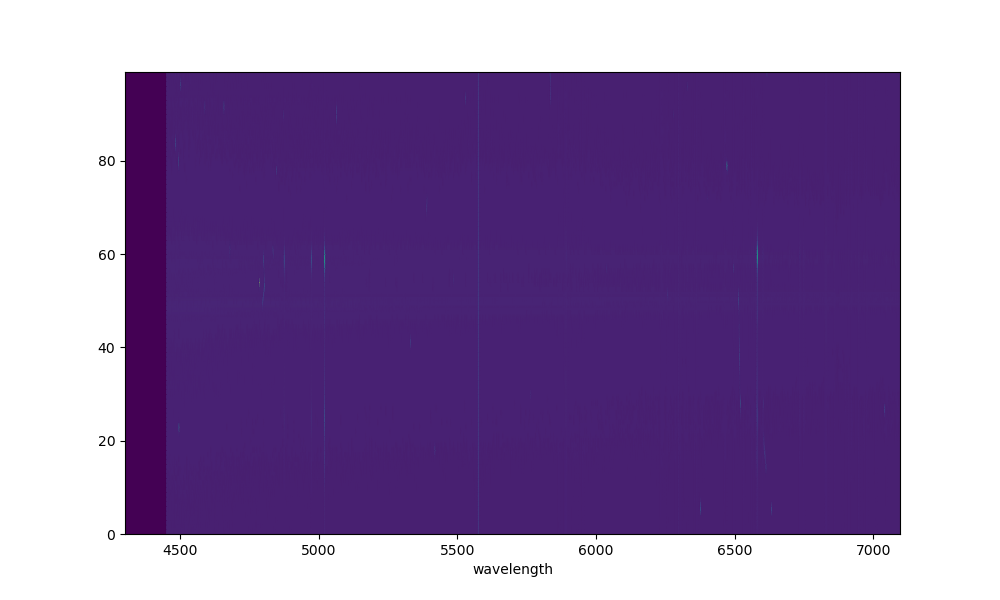

In [9]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC5058/FORS2.2022-01-28T08_17_47.181/NGC-5058_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[65:165, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

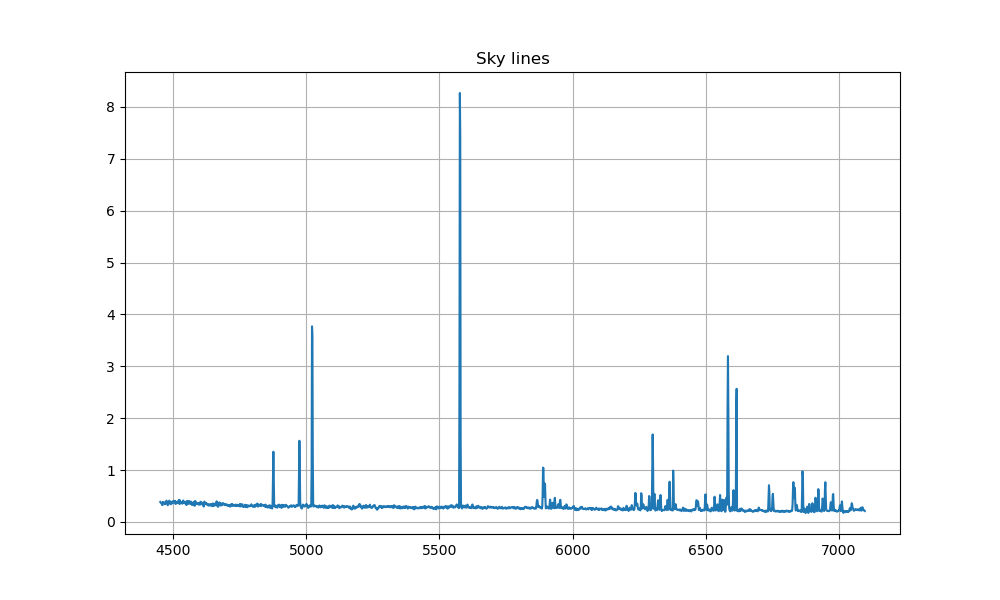

In [10]:
mask_sky = (y > 6)*(y < 16)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

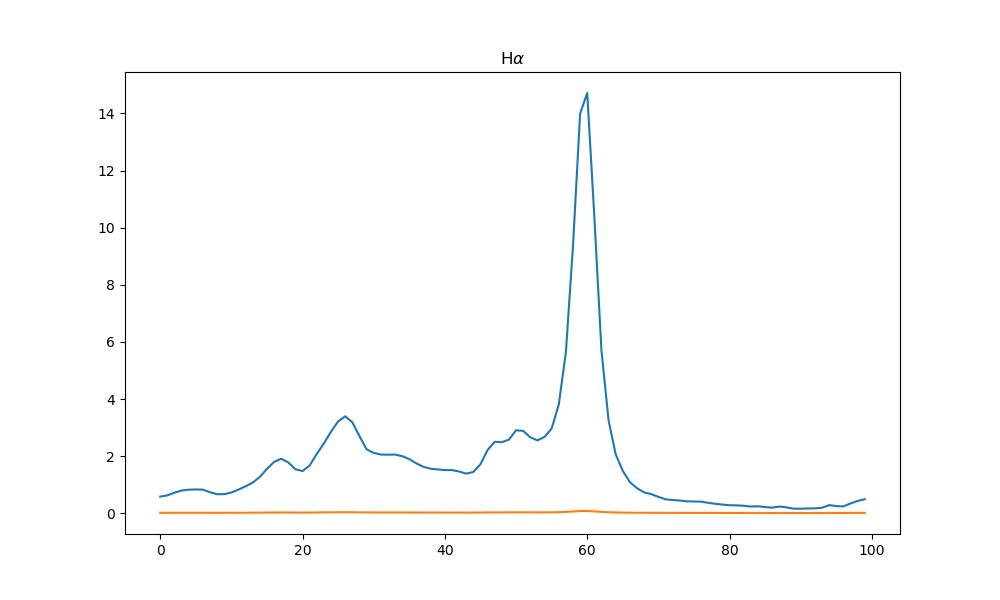

In [11]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [19]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 20)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 50),
    (0.1, 10),
    (13, 20),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (20, 28),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (30, 38),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (56, 64)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [15]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 55131.44838356799
differential_evolution step 2: f(x)= 55131.44838356799
differential_evolution step 3: f(x)= 55131.44838356799
differential_evolution step 4: f(x)= 49923.398075127436
differential_evolution step 5: f(x)= 49923.398075127436
differential_evolution step 6: f(x)= 12091.164893623521
differential_evolution step 7: f(x)= 12091.164893623521
differential_evolution step 8: f(x)= 12091.164893623521
differential_evolution step 9: f(x)= 9720.824000942954
differential_evolution step 10: f(x)= 7874.229924987064
differential_evolution step 11: f(x)= 6937.260622374434
differential_evolution step 12: f(x)= 1823.4724707416349
differential_evolution step 13: f(x)= 1823.4724707416349
differential_evolution step 14: f(x)= 1823.4724707416349
differential_evolution step 15: f(x)= 1823.4724707416349
differential_evolution step 16: f(x)= 1823.4724707416349
differential_evolution step 17: f(x)= 1823.4724707416349
differential_evolution step 18: f(x)= 1823.472

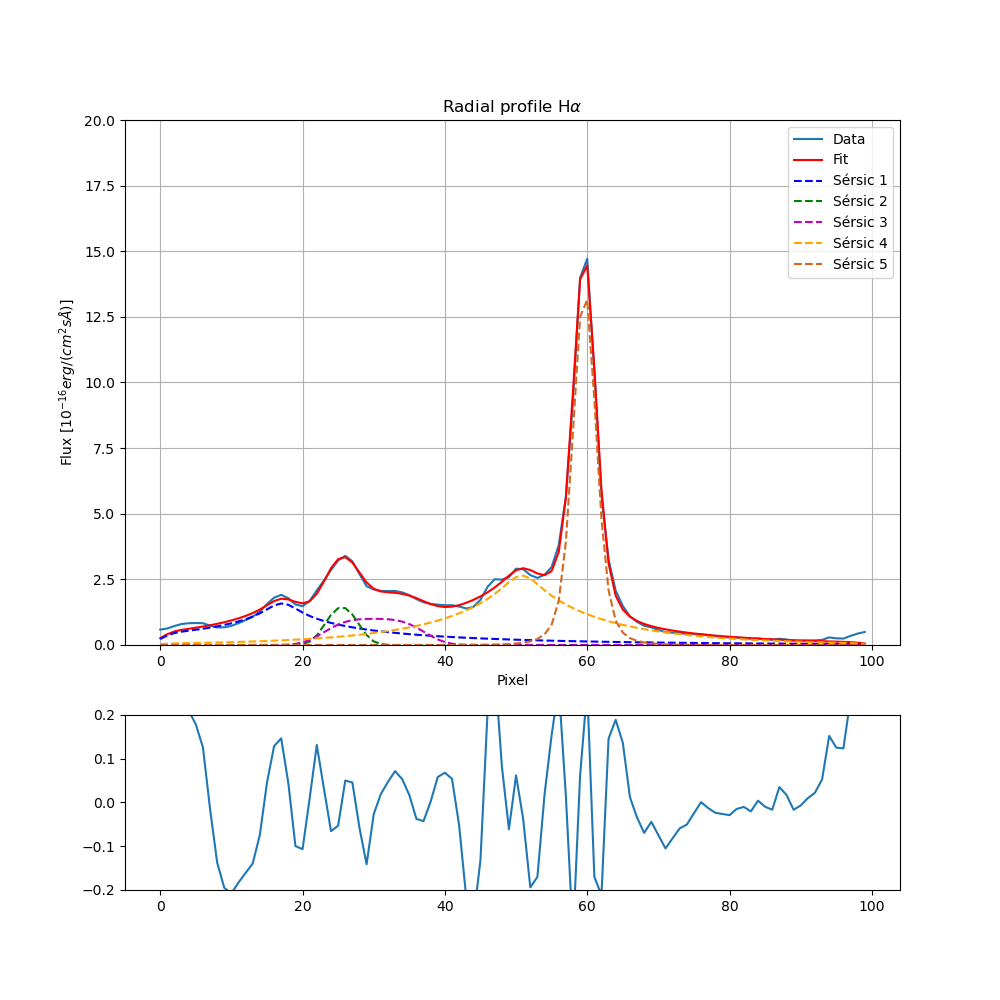

In [20]:
plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [21]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, 
                                           p0=result.x, sigma = radial_profile_error_HA, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1158, r_e=49.7964, n=1.5500, x_0=17.4725
Sérsic 2: I_e=1.4820, r_e=2.0700, n=0.1163, x_0=25.2596
Sérsic 3: I_e=0.6962, r_e=5.2515, n=0.3443, x_0=30.8967
Sérsic 4: I_e=0.2329, r_e=29.5147, n=1.5039, x_0=50.2106
Sérsic 5: I_e=1.8553, r_e=2.9298, n=1.9913, x_0=59.5881
[1.45031005e-01 6.52100472e+01 7.51231492e-01 1.53290503e+00
 5.45941154e+00 1.16842235e+01 1.99233582e+00 6.55166287e-01
 6.32032489e-01 4.55694725e+00 4.44974218e-01 7.97848654e+00
 1.17868260e-01 1.54874301e+01 3.37324166e-01 3.68824300e-01
 9.37544370e-01 8.75088028e-01 4.98666859e-01 4.20343570e-02]
41.52953692690228


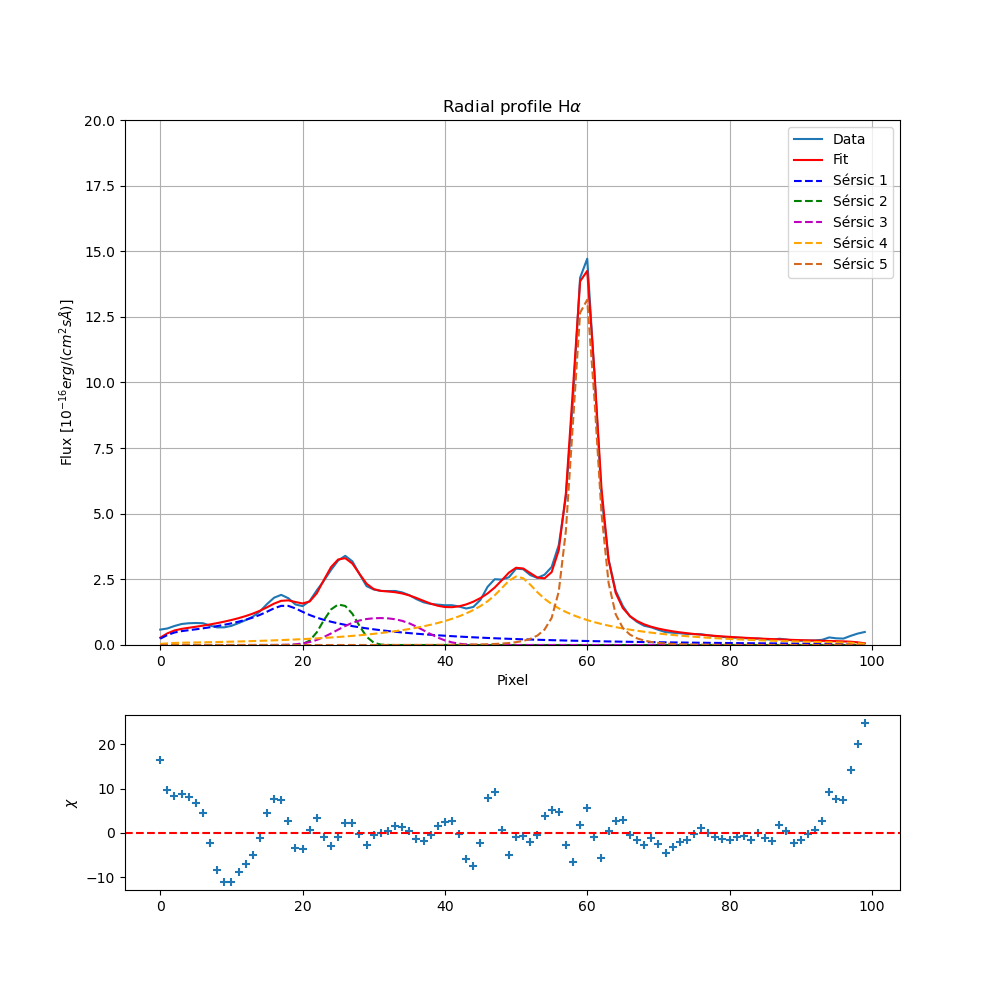

In [22]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [43]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.8, x_0_HA[0]+1.8),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.8, x_0_HA[1]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.8, x_0_HA[2]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.8, x_0_HA[3]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.8, x_0_HA[4]+1.8)
]

In [44]:
bounds

[(0, 20),
 (0, 50),
 (0.1, 10),
 (17.345299999999998, 20.9453),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (31.2, 34.8),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (45.631, 49.230999999999995),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (65.6252, 69.2252),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (78.3128, 81.91279999999999)]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

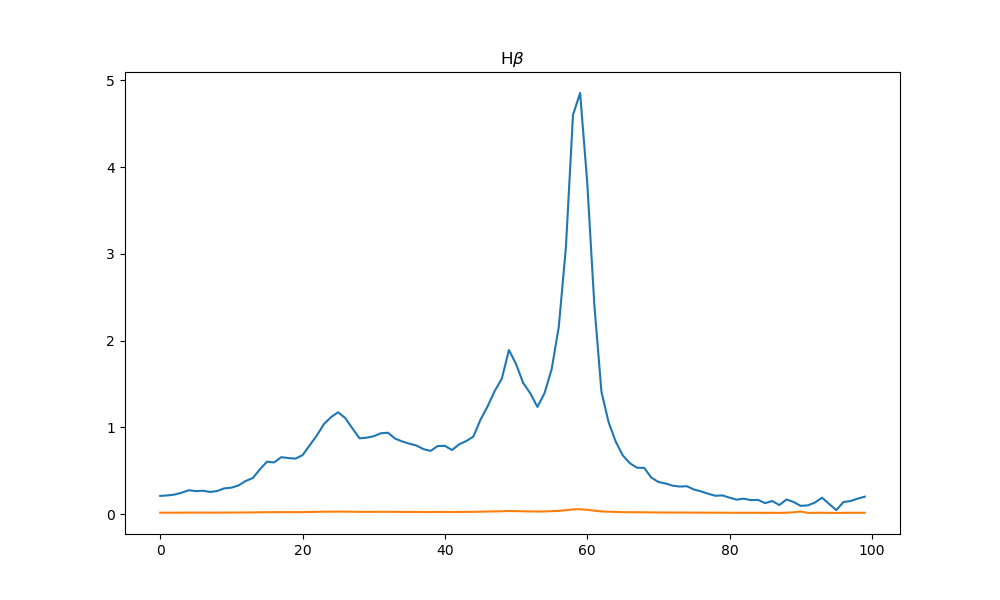

In [23]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [24]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 37716.681918867835
differential_evolution step 2: f(x)= 37716.681918867835
differential_evolution step 3: f(x)= 37716.681918867835
differential_evolution step 4: f(x)= 37716.681918867835
differential_evolution step 5: f(x)= 37716.681918867835
differential_evolution step 6: f(x)= 8631.37779325853
differential_evolution step 7: f(x)= 8631.37779325853
differential_evolution step 8: f(x)= 8631.37779325853
differential_evolution step 9: f(x)= 8631.37779325853
differential_evolution step 10: f(x)= 8631.37779325853
differential_evolution step 11: f(x)= 8631.37779325853
differential_evolution step 12: f(x)= 8631.37779325853
differential_evolution step 13: f(x)= 8631.37779325853
differential_evolution step 14: f(x)= 8631.37779325853
differential_evolution step 15: f(x)= 8631.37779325853
differential_evolution step 16: f(x)= 8631.37779325853
differential_evolution step 17: f(x)= 8631.37779325853
differential_evolution step 18: f(x)= 8631.37779325853
different

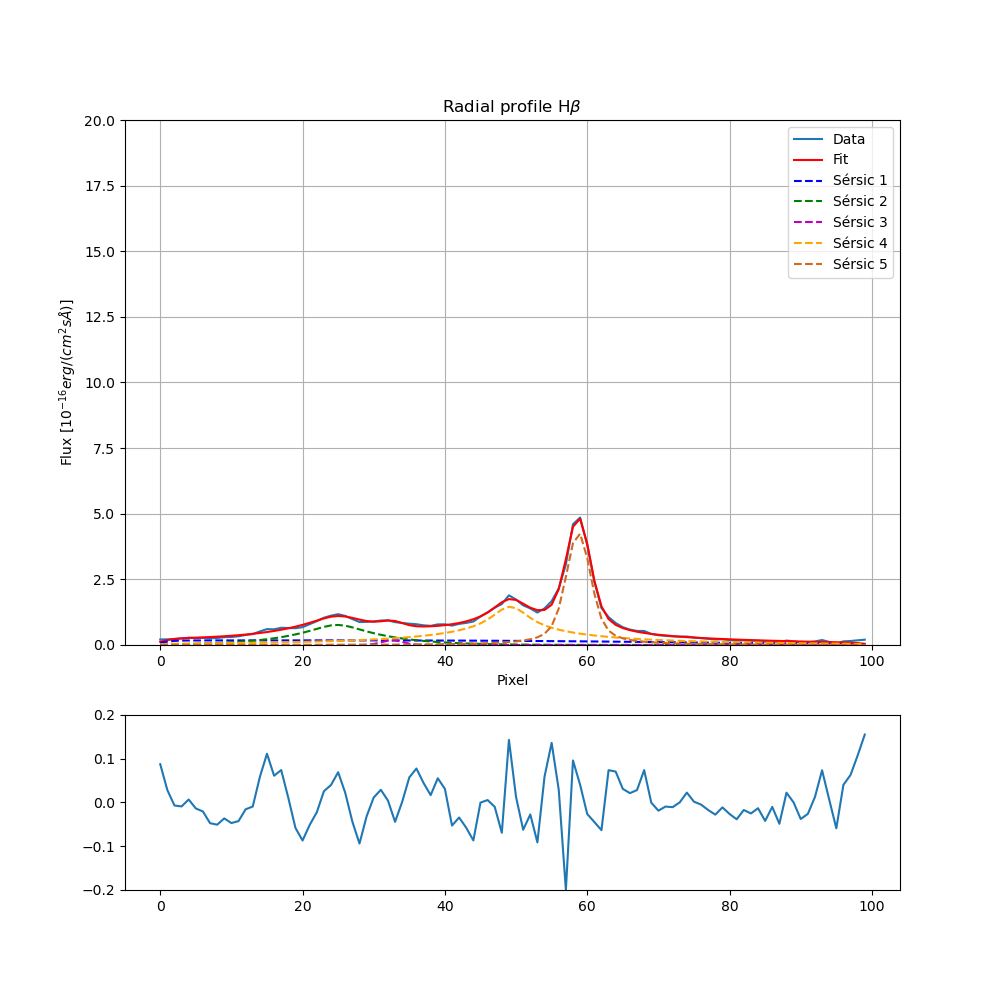

In [25]:
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [26]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1036, r_e=49.3147, n=0.3961, x_0=19.5031
Sérsic 2: I_e=0.1935, r_e=10.6873, n=0.9121, x_0=24.8610
Sérsic 3: I_e=5.0482, r_e=0.0406, n=0.2564, x_0=32.6372
Sérsic 4: I_e=0.0641, r_e=42.2864, n=1.9818, x_0=49.1658
Sérsic 5: I_e=0.0547, r_e=14.7859, n=3.9884, x_0=58.7469
[1.20195682e-01 9.58115187e+01 1.40471813e+00 1.44557907e+02
 1.04096776e-01 1.46473594e+01 5.35762334e-01 4.08523786e-01
 2.68391178e+06 4.33536813e+03 5.74021940e+05 2.53081814e+02
 1.53592066e-01 1.11997295e+02 1.61232193e+00 2.00527869e-01
 3.20332092e-01 5.81045643e+01 6.68443606e+00 4.02107869e-02]
6.805638022591722


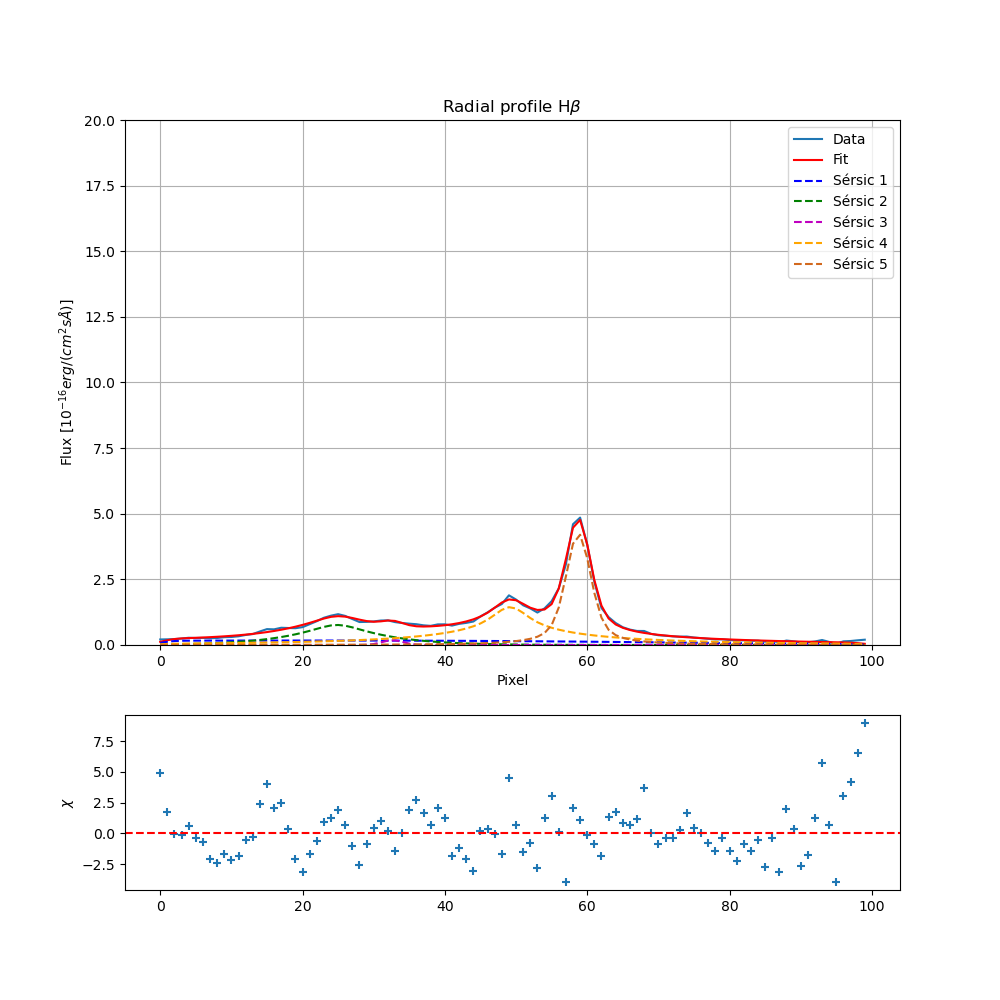

In [27]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

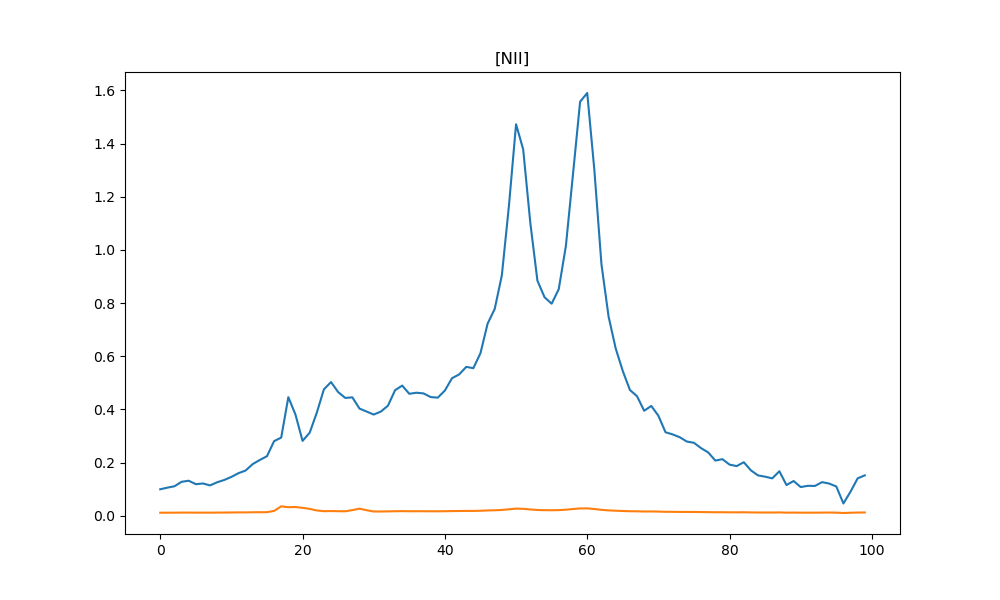

In [28]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [29]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 164673.62396976803
differential_evolution step 2: f(x)= 164673.62396976803
differential_evolution step 3: f(x)= 95143.7954043666
differential_evolution step 4: f(x)= 95143.7954043666
differential_evolution step 5: f(x)= 95143.7954043666
differential_evolution step 6: f(x)= 95143.7954043666
differential_evolution step 7: f(x)= 42002.17854302176
differential_evolution step 8: f(x)= 42002.17854302176
differential_evolution step 9: f(x)= 42002.17854302176
differential_evolution step 10: f(x)= 22569.09604814052
differential_evolution step 11: f(x)= 22569.09604814052
differential_evolution step 12: f(x)= 4675.260595528267
differential_evolution step 13: f(x)= 4675.260595528267
differential_evolution step 14: f(x)= 4675.260595528267
differential_evolution step 15: f(x)= 4675.260595528267
differential_evolution step 16: f(x)= 4675.260595528267
differential_evolution step 17: f(x)= 4675.260595528267
differential_evolution step 18: f(x)= 4675.260595528267
dif

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.1142, r_e=49.9811, n=0.1948, x_0=19.9177
Sérsic 2: I_e=0.1147, r_e=7.5485, n=0.4634, x_0=25.5321
Sérsic 3: I_e=0.5301, r_e=0.0384, n=3.6531, x_0=34.9610
Sérsic 4: I_e=0.0281, r_e=49.8405, n=2.3975, x_0=50.1685
Sérsic 5: I_e=0.0372, r_e=16.4520, n=2.6214, x_0=59.7119
Chi quadro minimo: 0.21126087929395876
False


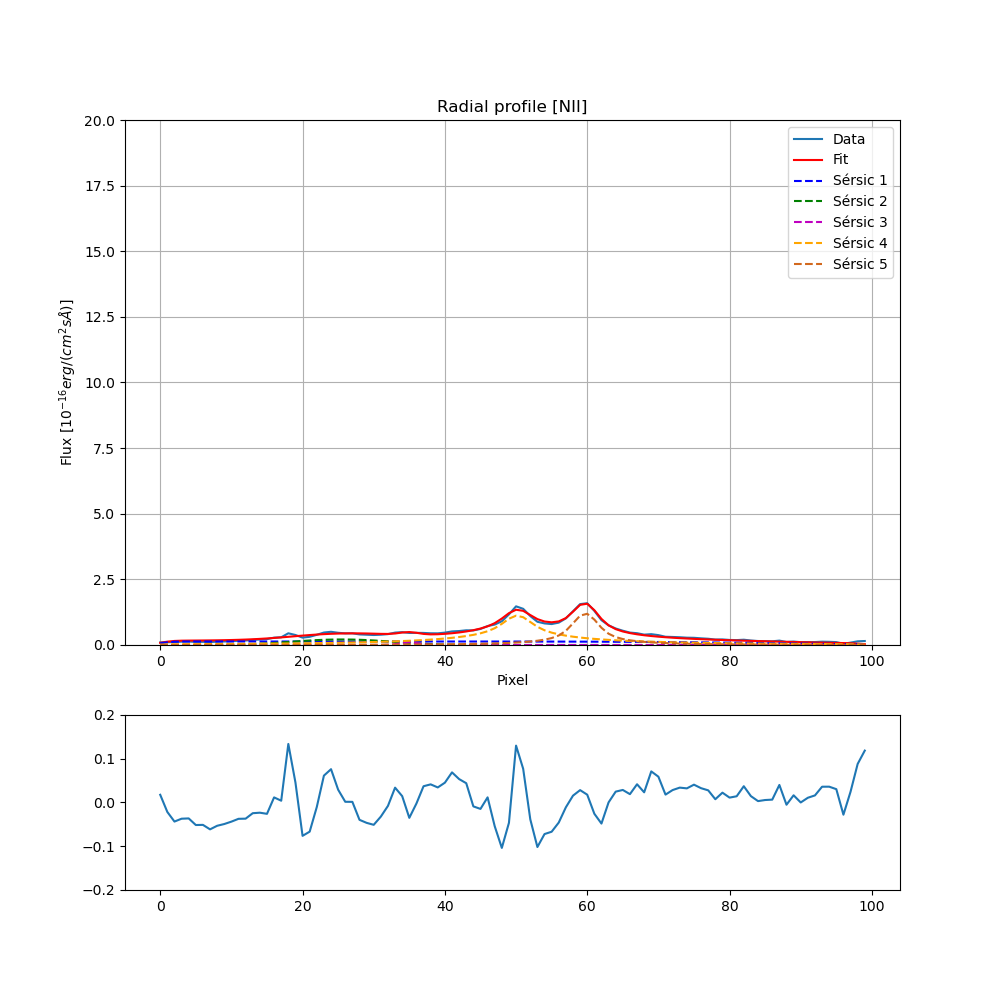

In [30]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [31]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0835, r_e=49.9816, n=0.1927, x_0=19.9194
Sérsic 2: I_e=0.1082, r_e=7.4591, n=0.5480, x_0=25.4877
Sérsic 3: I_e=0.5300, r_e=0.0412, n=3.6531, x_0=34.9624
Sérsic 4: I_e=0.0393, r_e=49.8415, n=2.0866, x_0=50.1742
Sérsic 5: I_e=0.0362, r_e=16.7456, n=2.5928, x_0=59.7614
[2.67978337e-01 7.49407762e+02 2.73377599e+00 1.01998877e+03
 3.96294852e-02 3.23810417e+00 2.96450867e-01 1.17072567e+00
 5.23016256e+03 6.60560361e+02 1.20778782e+05 5.37394703e+01
 7.07547603e-02 1.14614656e+02 1.14093513e+00 2.00641389e-01
 3.09430743e-01 1.12676623e+02 7.57592055e+00 2.26225956e-02]
8.313114030977207


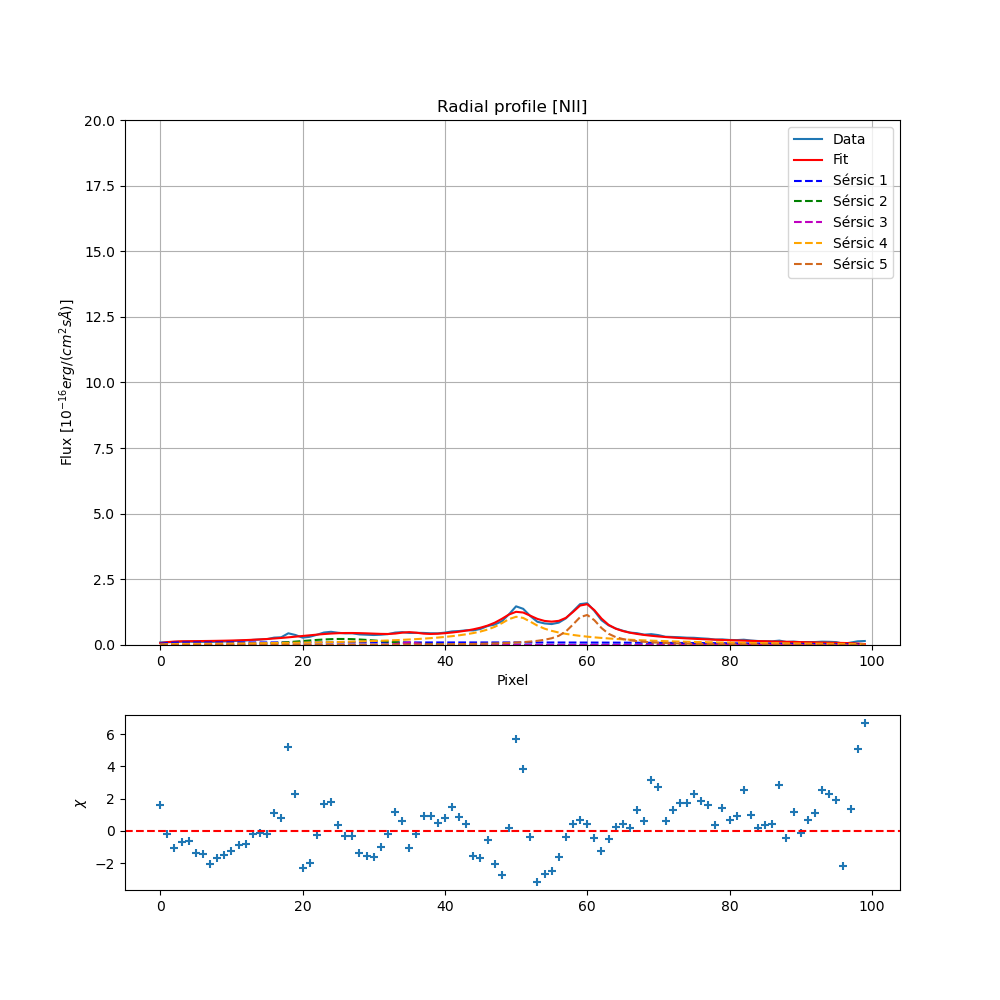

In [32]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

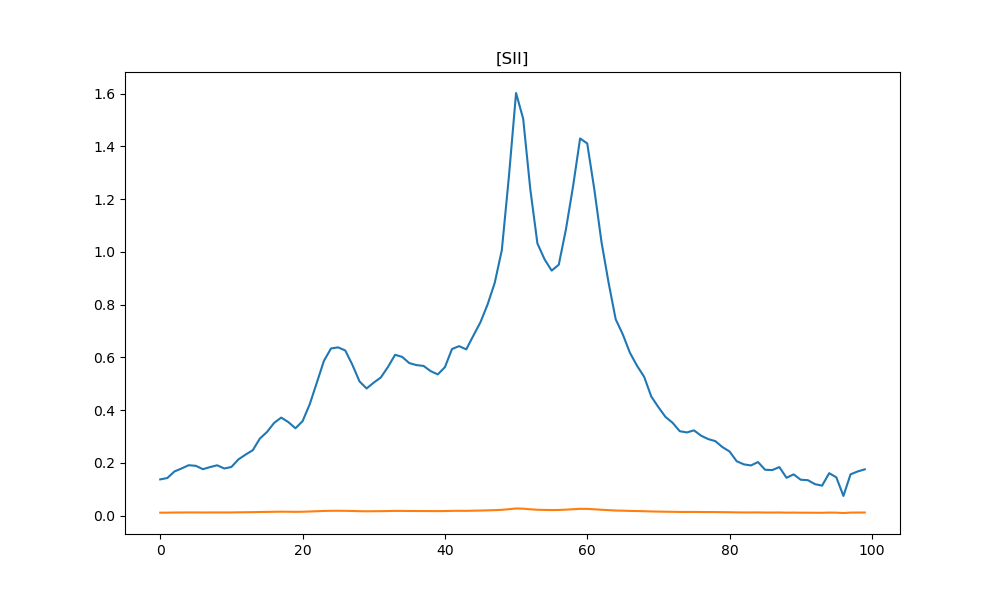

In [33]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [34]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 338779.83575341396
differential_evolution step 2: f(x)= 60428.25174136457
differential_evolution step 3: f(x)= 60428.25174136457
differential_evolution step 4: f(x)= 51996.178116128154
differential_evolution step 5: f(x)= 10070.131392535446
differential_evolution step 6: f(x)= 10070.131392535446
differential_evolution step 7: f(x)= 10070.131392535446
differential_evolution step 8: f(x)= 10070.131392535446
differential_evolution step 9: f(x)= 4119.266358731781
differential_evolution step 10: f(x)= 4119.266358731781
differential_evolution step 11: f(x)= 4119.266358731781
differential_evolution step 12: f(x)= 4119.266358731781
differential_evolution step 13: f(x)= 4119.266358731781
differential_evolution step 14: f(x)= 4119.266358731781
differential_evolution step 15: f(x)= 4119.266358731781
differential_evolution step 16: f(x)= 4119.266358731781
differential_evolution step 17: f(x)= 4119.266358731781
differential_evolution step 18: f(x)= 351.497947361

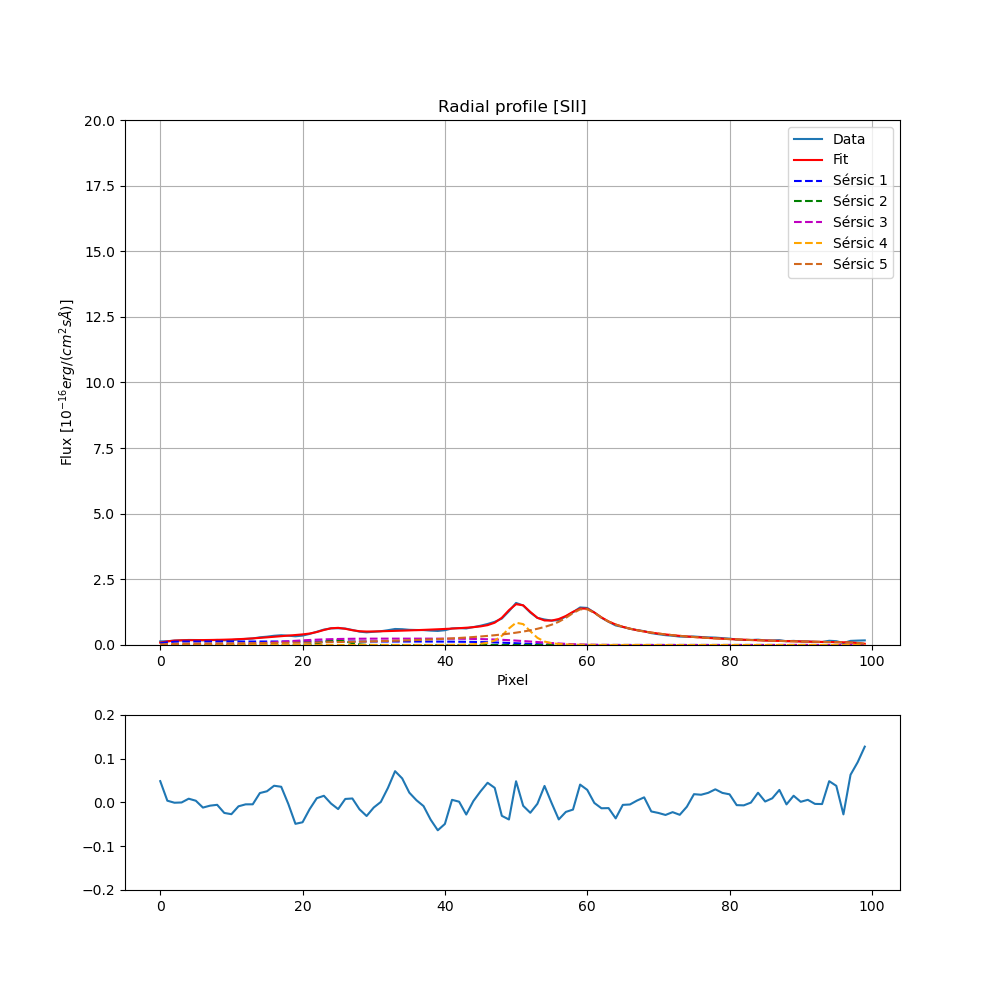

In [35]:
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [36]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1143, r_e=28.6334, n=0.1070, x_0=15.6265
Sérsic 2: I_e=0.2084, r_e=1.3470, n=0.1546, x_0=24.5714
Sérsic 3: I_e=0.1923, r_e=13.5630, n=0.2340, x_0=34.7314
Sérsic 4: I_e=0.1409, r_e=2.9082, n=1.7299, x_0=50.3111
Sérsic 5: I_e=0.0624, r_e=49.9082, n=1.9077, x_0=59.4891
[4.55731543e-01 7.32764223e+02 2.17592730e+00 6.17767470e+02
 1.89236536e-01 8.14510899e+00 4.37425946e+00 3.32649447e-01
 4.89898412e-02 6.90655134e+00 1.35305368e-01 1.03592782e+01
 1.40821347e+00 2.63918421e+01 7.34744954e+00 1.88359207e-01
 2.24884459e-02 1.29021219e+01 2.93063746e-01 4.08742799e-02]
5.436590879139857


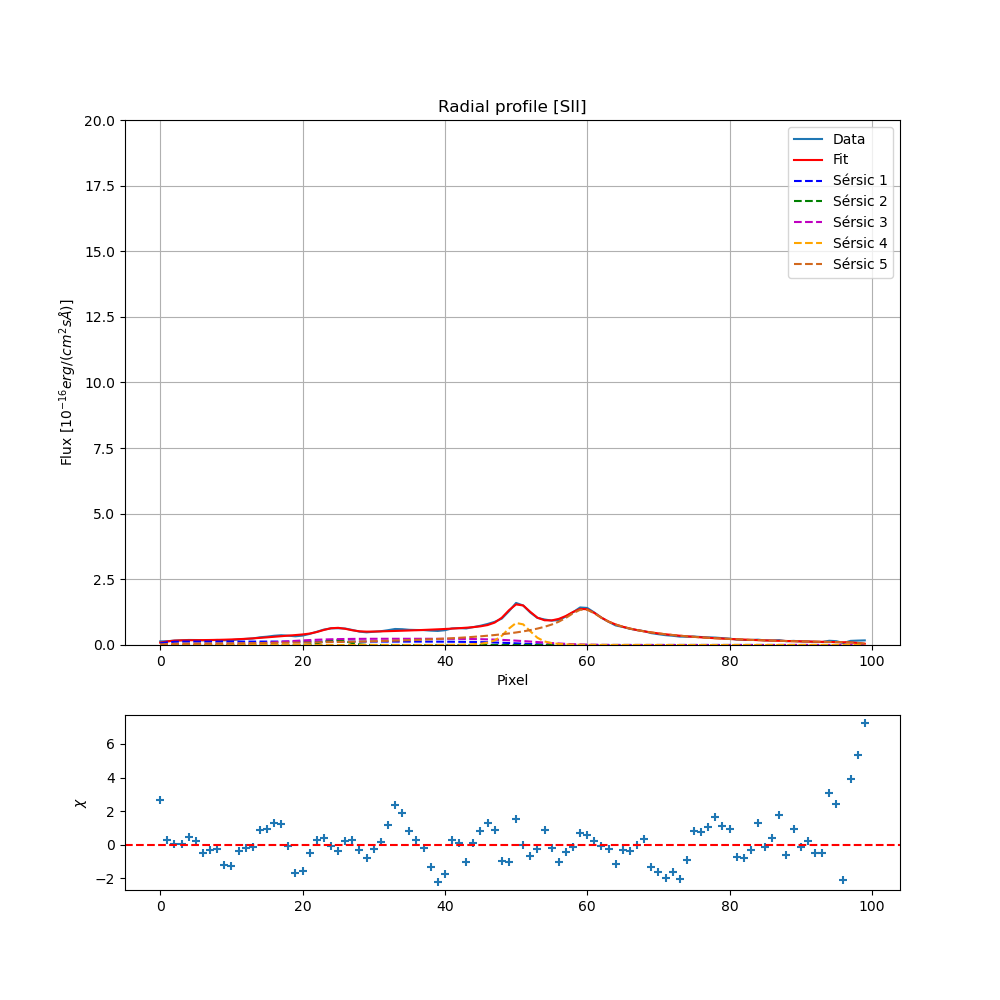

In [37]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

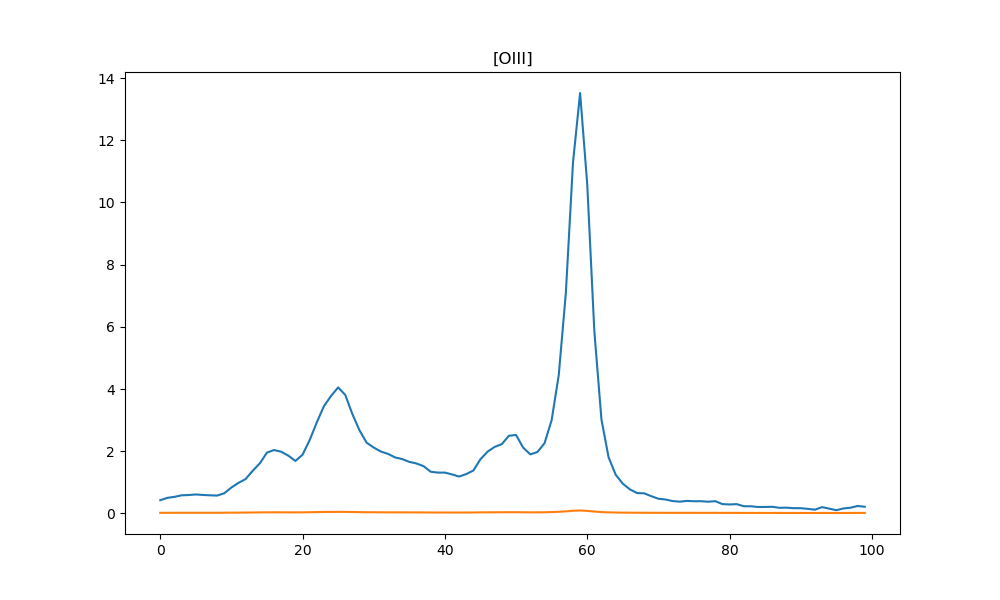

In [38]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [39]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 272511.68189649505
differential_evolution step 2: f(x)= 169143.8795035601
differential_evolution step 3: f(x)= 169143.8795035601
differential_evolution step 4: f(x)= 65265.00647742066
differential_evolution step 5: f(x)= 62300.10725382268
differential_evolution step 6: f(x)= 62300.10725382268
differential_evolution step 7: f(x)= 23851.59985357014
differential_evolution step 8: f(x)= 19831.814180669116
differential_evolution step 9: f(x)= 18964.848938542076
differential_evolution step 10: f(x)= 18964.848938542076
differential_evolution step 11: f(x)= 17182.02175698552
differential_evolution step 12: f(x)= 5091.478848675237
differential_evolution step 13: f(x)= 2931.3245544748393
differential_evolution step 14: f(x)= 2931.3245544748393
differential_evolution step 15: f(x)= 2931.3245544748393
differential_evolution step 16: f(x)= 1972.7668257698035
differential_evolution step 17: f(x)= 1972.7668257698035
differential_evolution step 18: f(x)= 1937.28937

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:67: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


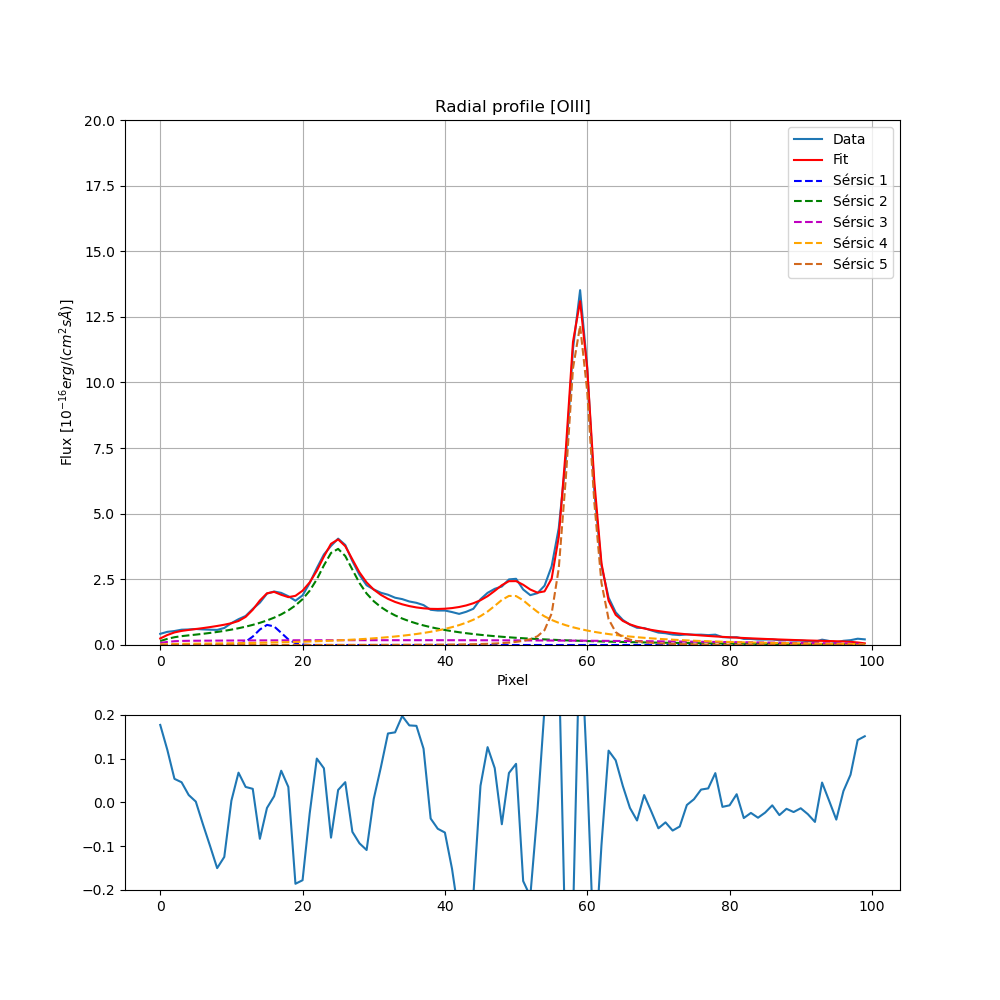

In [40]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [41]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = radial_profile_error_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=1.0657, r_e=1.0644, n=0.1465, x_0=15.2728
Sérsic 2: I_e=0.1931, r_e=33.1045, n=1.9063, x_0=24.9342
Sérsic 3: I_e=0.0778, r_e=85.2455, n=0.3867, x_0=10.8334
Sérsic 4: I_e=0.1338, r_e=26.3143, n=1.6995, x_0=49.2729
Sérsic 5: I_e=0.4354, r_e=5.3026, n=3.4452, x_0=58.8702
[7.71636213e-01 2.65723959e+01 1.44457984e+01 2.62245795e-01
 4.04274404e-01 9.65588174e+01 1.33978342e+00 1.39659634e-01
 2.02150424e+00 1.10279997e+03 1.78422963e+01 2.99200553e+03
 2.08564557e-01 5.26535710e+01 1.02306422e+00 2.78956034e-01
 2.03988254e+00 1.44248135e+01 8.88691472e+00 7.32586038e-04]
16.137040033529328


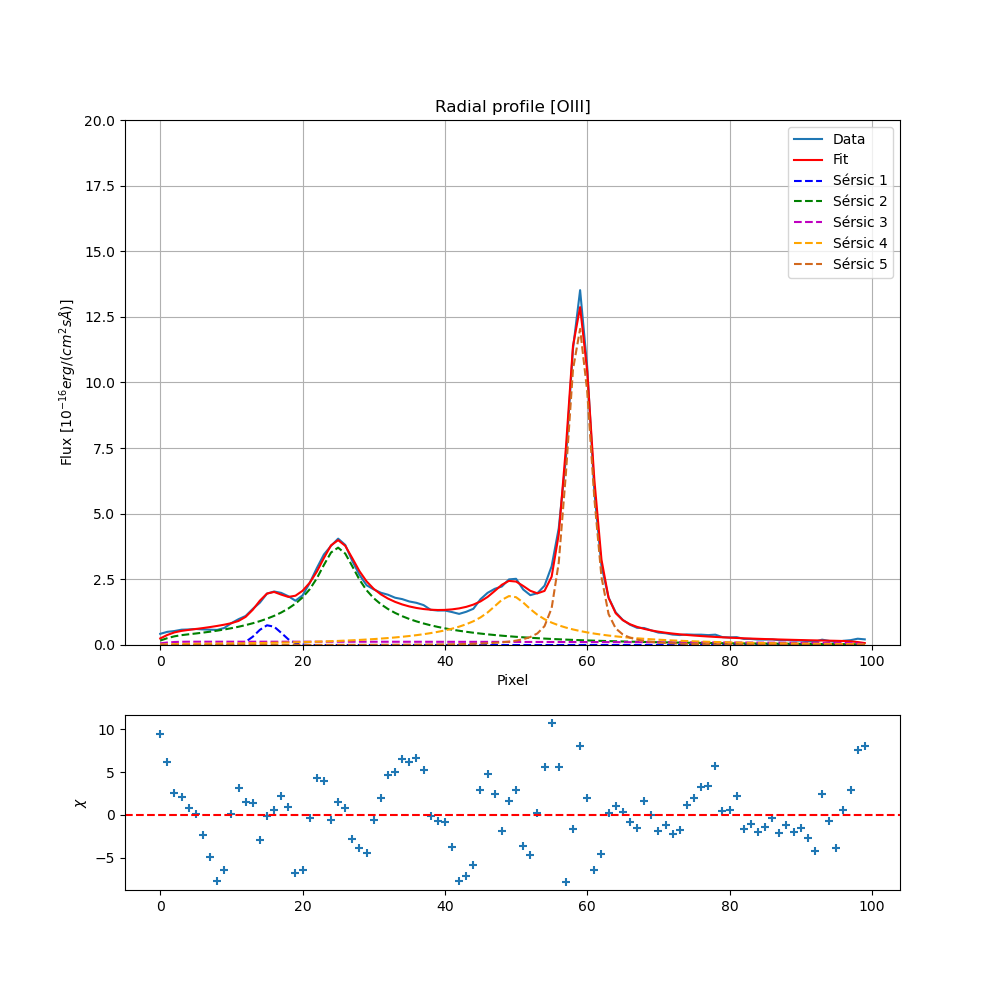

In [42]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [43]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

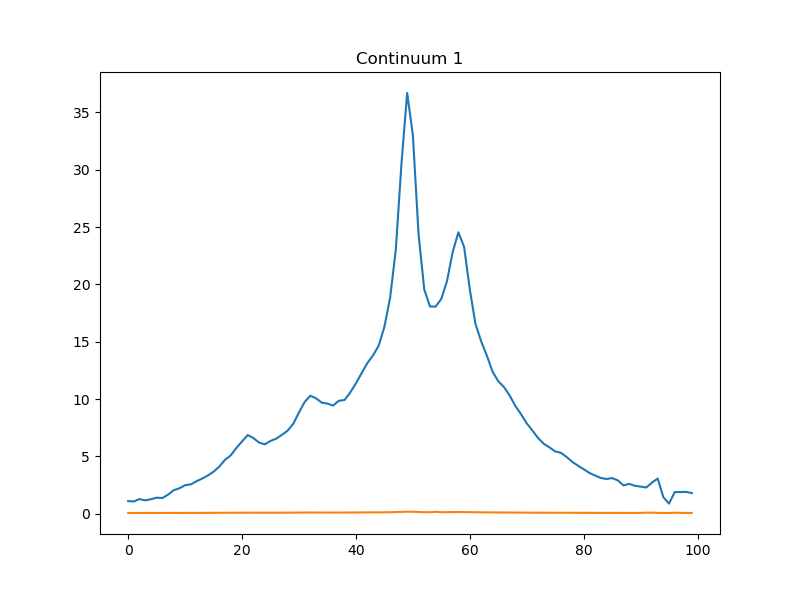

In [44]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [45]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 71604.87744246036
differential_evolution step 2: f(x)= 42090.700920222414
differential_evolution step 3: f(x)= 10305.003218642954
differential_evolution step 4: f(x)= 10305.003218642954
differential_evolution step 5: f(x)= 10305.003218642954
differential_evolution step 6: f(x)= 10305.003218642954
differential_evolution step 7: f(x)= 10305.003218642954
differential_evolution step 8: f(x)= 8093.943222118527
differential_evolution step 9: f(x)= 8093.943222118527
differential_evolution step 10: f(x)= 8093.943222118527
differential_evolution step 11: f(x)= 8093.943222118527
differential_evolution step 12: f(x)= 8093.943222118527
differential_evolution step 13: f(x)= 5758.06476941597
differential_evolution step 14: f(x)= 5758.06476941597
differential_evolution step 15: f(x)= 4579.267880369919
differential_evolution step 16: f(x)= 4579.267880369919
differential_evolution step 17: f(x)= 4579.267880369919
differential_evolution step 18: f(x)= 4579.2678803699

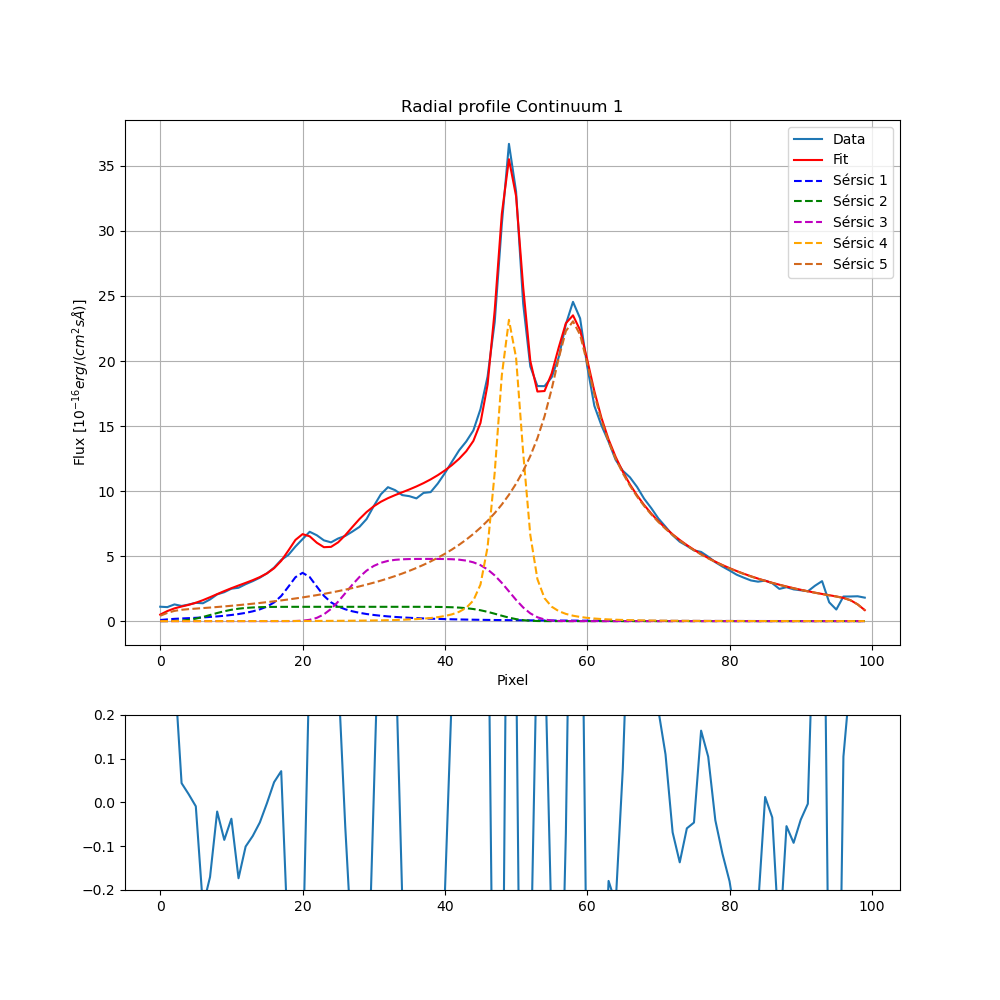

In [46]:
def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [47]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1490, r_e=20.9143, n=2.2751, x_0=20.0000
Sérsic 2: I_e=0.9146, r_e=16.6228, n=0.1060, x_0=27.3258
Sérsic 3: I_e=4.0499, r_e=8.6177, n=0.2000, x_0=37.6710
Sérsic 4: I_e=1.2285, r_e=5.2844, n=2.8543, x_0=49.0915
Sérsic 5: I_e=1.5974, r_e=40.6495, n=1.6508, x_0=57.9436
[5.73802187e-01 5.55444159e+01 2.79032925e+00 5.03404066e-01
 1.49246475e+00 1.40381477e+01 2.29209385e-01 8.12853608e+00
 1.34788427e+00 8.78614816e+00 2.57057326e-01 1.21638565e+01
 1.90492707e+01 4.06196665e+01 2.42402420e+01 1.14941703e-02
 3.40574419e-01 5.30881362e+00 1.21885228e-01 2.59548815e-01]
26.832054657194732


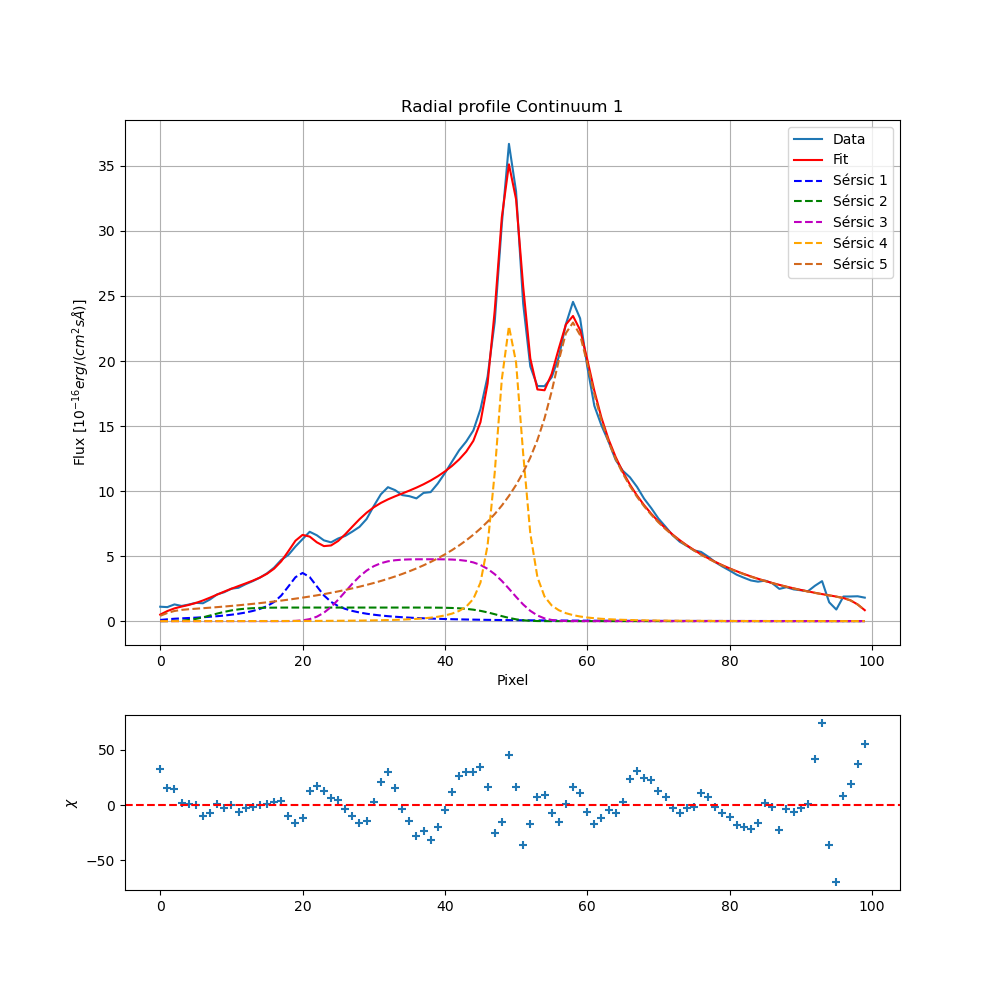

In [48]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

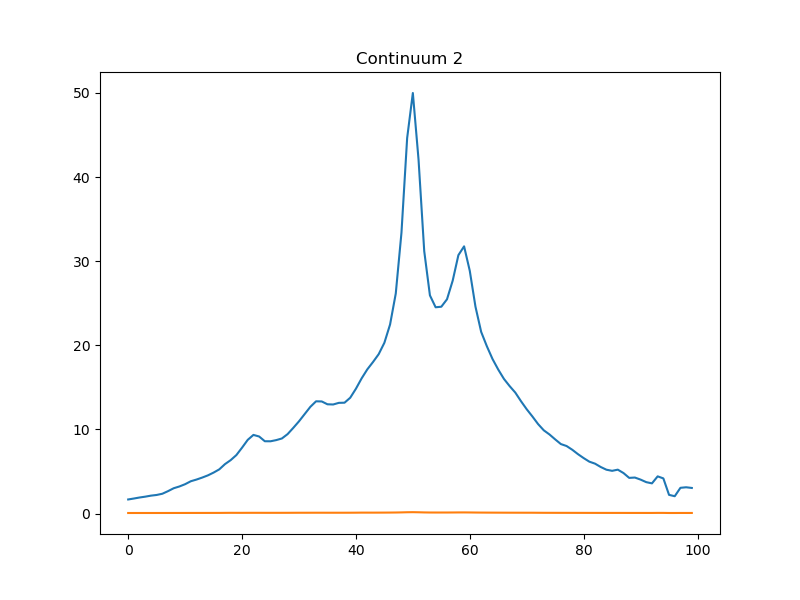

In [49]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [50]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 586931.8213882619
differential_evolution step 2: f(x)= 28136.908529469514
differential_evolution step 3: f(x)= 28136.908529469514
differential_evolution step 4: f(x)= 28136.908529469514
differential_evolution step 5: f(x)= 4033.0864185885484
differential_evolution step 6: f(x)= 4033.0864185885484
differential_evolution step 7: f(x)= 3445.3573268262203
differential_evolution step 8: f(x)= 3445.3573268262203
differential_evolution step 9: f(x)= 3445.3573268262203
differential_evolution step 10: f(x)= 2035.2493399105374
differential_evolution step 11: f(x)= 2035.2493399105374
differential_evolution step 12: f(x)= 2035.2493399105374
differential_evolution step 13: f(x)= 2035.2493399105374
differential_evolution step 14: f(x)= 2035.2493399105374
differential_evolution step 15: f(x)= 2035.2493399105374
differential_evolution step 16: f(x)= 1542.710891917527
differential_evolution step 17: f(x)= 1542.710891917527
differential_evolution step 18: f(x)= 1542.

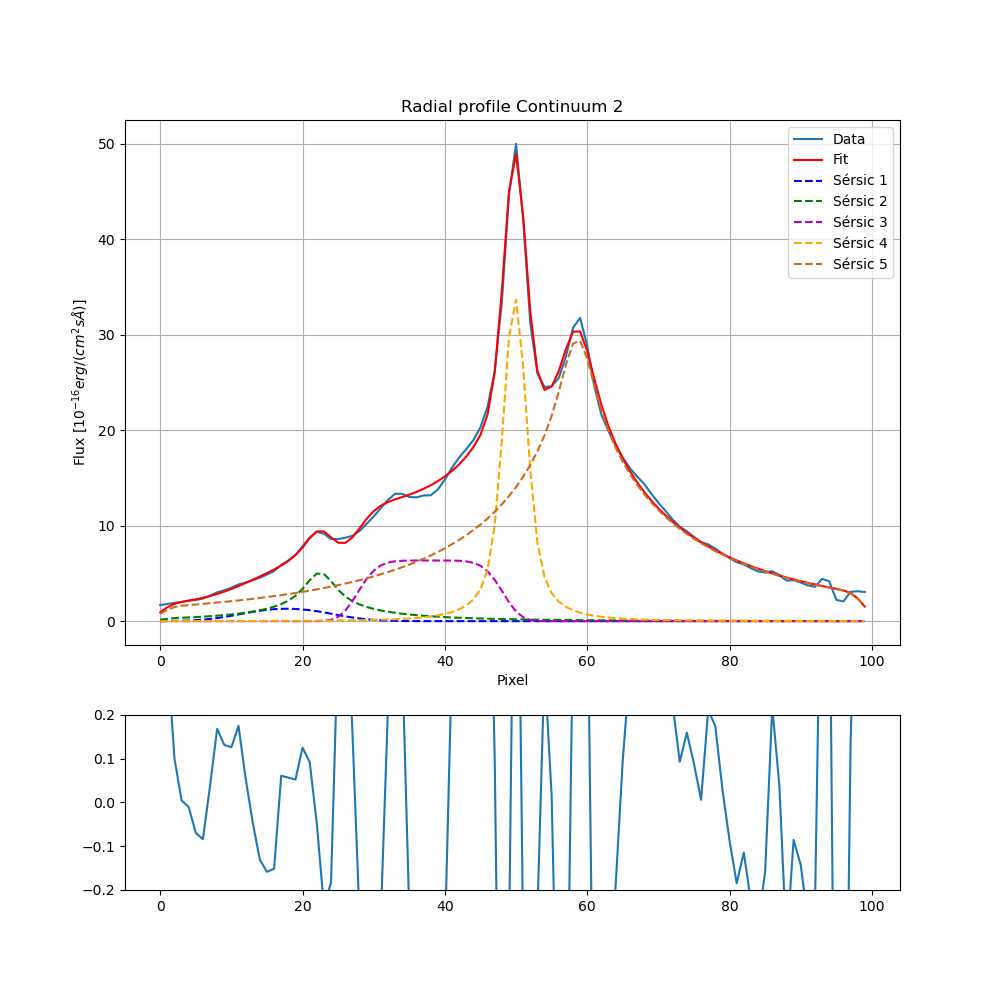

In [51]:
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [52]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[5], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2, radial_profile_error_continuum_2,
                                                                          sigmas[5], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.7564, r_e=6.5355, n=0.4356, x_0=17.7603
Sérsic 2: I_e=0.2562, r_e=23.2818, n=1.9813, x_0=22.4308
Sérsic 3: I_e=5.6550, r_e=7.8257, n=0.1407, x_0=37.9385
Sérsic 4: I_e=1.6152, r_e=6.5589, n=2.7205, x_0=49.8342
Sérsic 5: I_e=2.0505, r_e=49.2651, n=1.6199, x_0=58.6457
[3.50132231e+00 1.58314438e+01 8.90663501e-01 3.00361010e+01
 2.21784284e+00 1.20730107e+02 4.57242976e+00 1.02763238e+00
 1.28287880e+00 1.44395273e+00 7.78935803e-02 9.36441562e-01
 9.41928000e+00 2.41981957e+01 7.53542167e+00 2.75503224e-03
 3.63150216e-01 6.37354720e+00 8.65177703e-02 1.55424123e-01]
33.37451177900776


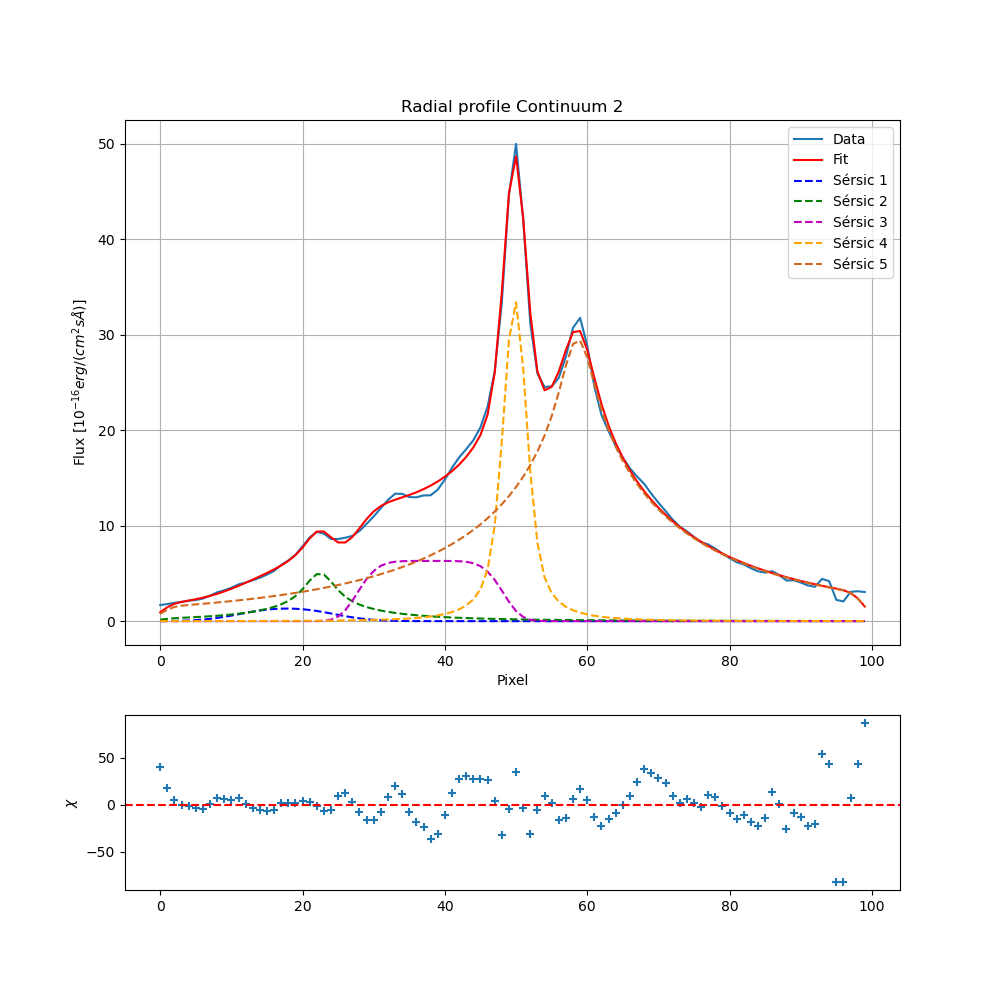

In [53]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

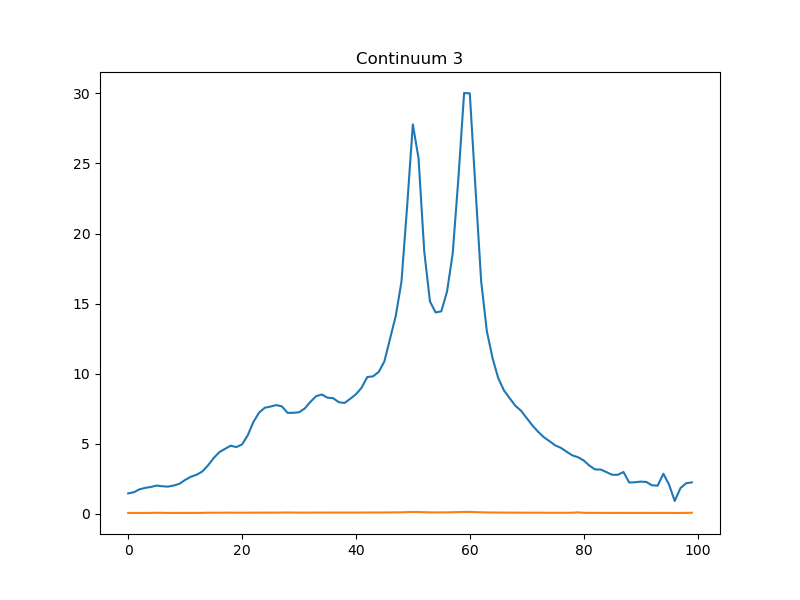

In [54]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [55]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 245109.90017403217
differential_evolution step 2: f(x)= 245109.90017403217
differential_evolution step 3: f(x)= 109131.1757423363
differential_evolution step 4: f(x)= 109131.1757423363
differential_evolution step 5: f(x)= 36287.43947726061
differential_evolution step 6: f(x)= 36287.43947726061
differential_evolution step 7: f(x)= 36287.43947726061
differential_evolution step 8: f(x)= 8874.188489510123
differential_evolution step 9: f(x)= 8874.188489510123
differential_evolution step 10: f(x)= 8874.188489510123
differential_evolution step 11: f(x)= 8497.558577334883
differential_evolution step 12: f(x)= 5116.34655066366
differential_evolution step 13: f(x)= 5116.34655066366
differential_evolution step 14: f(x)= 5116.34655066366
differential_evolution step 15: f(x)= 5116.34655066366
differential_evolution step 16: f(x)= 5116.34655066366
differential_evolution step 17: f(x)= 5116.34655066366
differential_evolution step 18: f(x)= 5116.34655066366
differ

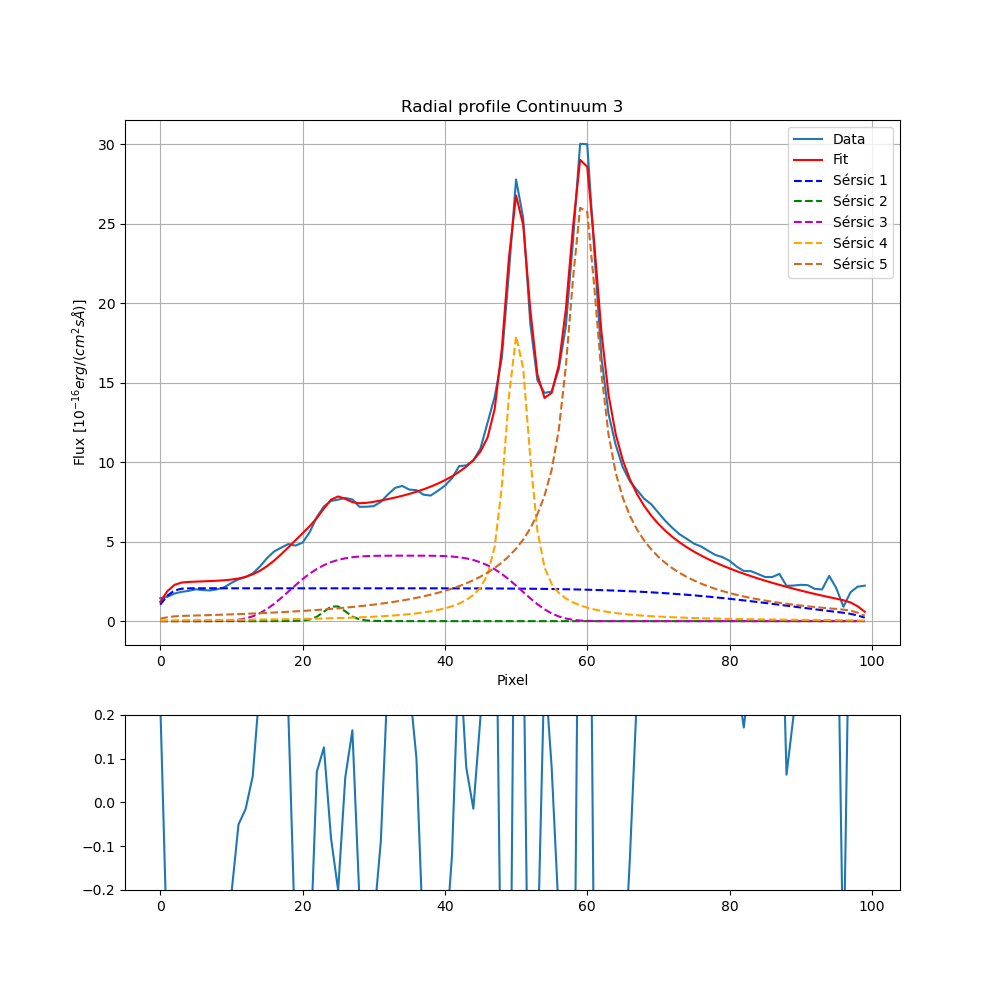

In [56]:
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [57]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          radial_profile_error_continuum_3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_19028\1936392938.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.4569, r_e=53.8603, n=0.1533, x_0=28.3254
Sérsic 2: I_e=0.3108, r_e=0.6818, n=2.4366, x_0=24.6074
Sérsic 3: I_e=3.5919, r_e=12.3184, n=0.2278, x_0=33.8212
Sérsic 4: I_e=0.0703, r_e=43.3857, n=4.6278, x_0=50.1567
Sérsic 5: I_e=0.3844, r_e=57.7284, n=2.8546, x_0=59.3653
[7.37483468e-01 5.41584607e+02 1.44574435e+00 6.17068253e+02
 5.43213567e+01 4.89517631e+01 1.92286627e+02 8.27658430e-01
 9.61363593e-01 2.94821335e+00 8.88593296e-02 4.65532358e+00
 1.12250408e+00 5.01230913e+02 1.53606599e+01 6.85681194e-02
 1.17976265e+00 1.53559668e+02 2.32824069e+00 1.73269869e-03]
55.651823655205575


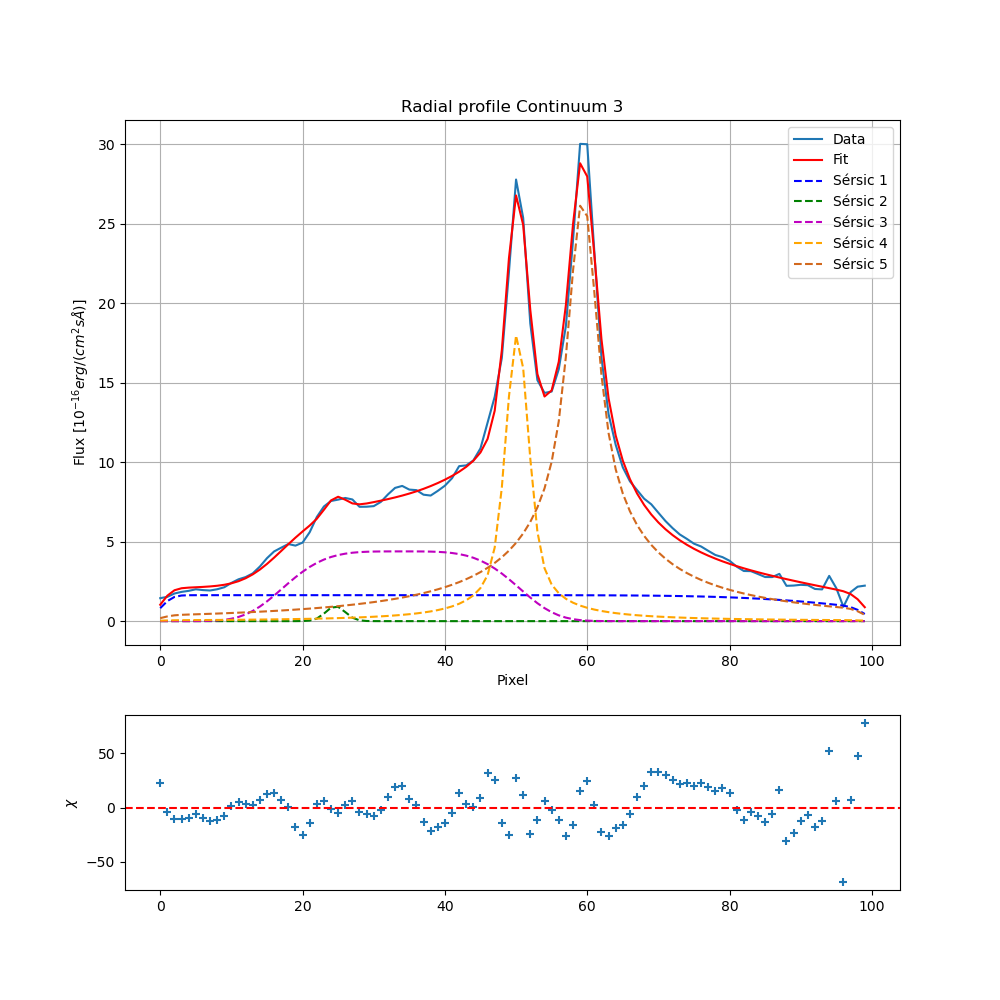

In [58]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [59]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [60]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
